<a href="https://colab.research.google.com/github/3011stan/ann-exercises-ifes/blob/main/02_mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificacao do MNIST original com CNN

Esta atividade baixa os arquivos originais do MNIST em formato IDX, faz a leitura e o preprocessamento manual dos dados e treina uma rede neural convolucional para classificar os digitos.

O ponto principal do exercicio e nao usar `keras.datasets.mnist.load_data()`. Keras/TensorFlow sera usado apenas para construir e treinar a CNN.

## Bibliotecas

A leitura do dataset usa apenas bibliotecas padrao do Python, NumPy e funcoes simples para interpretar o formato IDX. O modelo e definido com TensorFlow/Keras.

In [1]:
import gzip
import struct
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid')

## Constantes

O dataset completo sera baixado e preprocessado. O modelo usa `TRAIN_LIMIT = 60000` por padrao para treinar com todo o conjunto de treino original no Colab.

In [2]:
RANDOM_STATE = 42
TRAIN_LIMIT = 60000
EPOCHS = 3
BATCH_SIZE = 128

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_DIR = Path('data/mnist')
BASE_URL = 'https://raw.githubusercontent.com/fgnt/mnist/master/'

FILES = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images': 't10k-images-idx3-ubyte.gz',
    'test_labels': 't10k-labels-idx1-ubyte.gz',
}

print('TensorFlow:', tf.__version__)
print('Diretorio dos dados:', DATA_DIR)

TensorFlow: 2.20.0
Diretorio dos dados: data/mnist


## Download dos arquivos IDX

Os arquivos abaixo sao um mirror dos arquivos originais do MNIST. Eles mantem os nomes e formatos IDX usados no site original do Yann LeCun. O download usa `urllib.request.urlretrieve`, da biblioteca padrao.

In [3]:
def download_mnist_files(base_url=BASE_URL, data_dir=DATA_DIR):
    data_dir.mkdir(parents=True, exist_ok=True)
    paths = {}
    for key, filename in FILES.items():
        path = data_dir / filename
        url = base_url + filename
        if path.exists():
            print(f'Reutilizando {path}')
        else:
            print(f'Baixando {url}')
            urlretrieve(url, path)
        paths[key] = path
    return paths


mnist_paths = download_mnist_files()

Baixando https://raw.githubusercontent.com/fgnt/mnist/master/train-images-idx3-ubyte.gz
Baixando https://raw.githubusercontent.com/fgnt/mnist/master/train-labels-idx1-ubyte.gz
Baixando https://raw.githubusercontent.com/fgnt/mnist/master/t10k-images-idx3-ubyte.gz
Baixando https://raw.githubusercontent.com/fgnt/mnist/master/t10k-labels-idx1-ubyte.gz


## Leitura manual do formato IDX

As funcoes a seguir abrem os arquivos `.gz`, validam os magic numbers, verificam as dimensoes esperadas e convertem os bytes para arrays NumPy. Isso deixa explicito que os dados foram baixados e preprocessados no notebook, sem loader pronto do Keras ou TorchVision.

In [4]:
def read_idx_images(path):
    with gzip.open(path, 'rb') as file:
        magic, n_images, rows, cols = struct.unpack('>IIII', file.read(16))
        if magic != 2051:
            raise ValueError(f'Magic number invalido para imagens: {magic}')
        if rows != 28 or cols != 28:
            raise ValueError(f'Dimensoes inesperadas: {rows}x{cols}')
        data = np.frombuffer(file.read(), dtype=np.uint8)
    expected = n_images * rows * cols
    if data.size != expected:
        raise ValueError(f'Esperado {expected} pixels, recebido {data.size}')
    return data.reshape(n_images, rows, cols)


def read_idx_labels(path):
    with gzip.open(path, 'rb') as file:
        magic, n_labels = struct.unpack('>II', file.read(8))
        if magic != 2049:
            raise ValueError(f'Magic number invalido para rotulos: {magic}')
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    if labels.size != n_labels:
        raise ValueError(f'Esperado {n_labels} rotulos, recebido {labels.size}')
    return labels


train_images_raw = read_idx_images(mnist_paths['train_images'])
train_labels = read_idx_labels(mnist_paths['train_labels'])
test_images_raw = read_idx_images(mnist_paths['test_images'])
test_labels = read_idx_labels(mnist_paths['test_labels'])

print('train_images_raw:', train_images_raw.shape, train_images_raw.dtype)
print('train_labels:', train_labels.shape, train_labels.dtype)
print('test_images_raw:', test_images_raw.shape, test_images_raw.dtype)
print('test_labels:', test_labels.shape, test_labels.dtype)
print('Classes:', np.unique(train_labels))

train_images_raw: (60000, 28, 28) uint8
train_labels: (60000,) uint8
test_images_raw: (10000, 28, 28) uint8
test_labels: (10000,) uint8
Classes: [0 1 2 3 4 5 6 7 8 9]


## Exemplos do dataset

Antes do preprocessamento, as imagens ainda estao no formato original `uint8`, com valores de pixel entre 0 e 255.

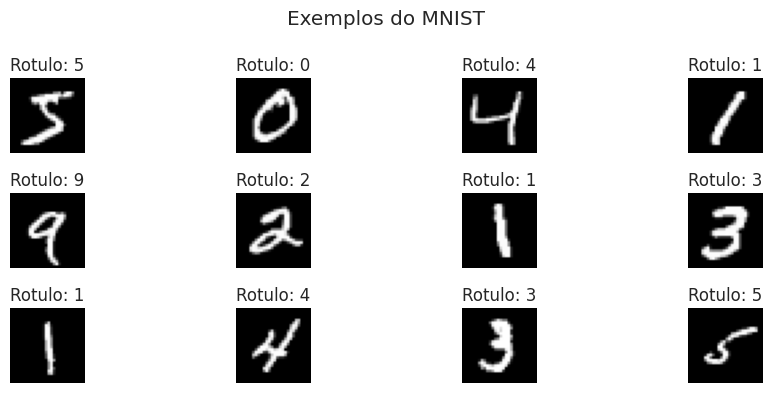

In [5]:
def plot_digit_examples(images, labels, n=12, title='Exemplos do MNIST'):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f'Rotulo: {labels[i]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_digit_examples(train_images_raw, train_labels, n=12)

## Preprocessamento

O preprocessamento converte os pixels para `float32`, normaliza para o intervalo `[0, 1]` e adiciona a dimensao do canal, resultando em `(N, 28, 28, 1)`, formato esperado pela CNN no Keras.

In [6]:
def preprocess_images(images):
    images = images.astype('float32') / 255.0
    return images.reshape((-1, 28, 28, 1))


train_images = preprocess_images(train_images_raw)
test_images = preprocess_images(test_images_raw)

x_train = train_images[:TRAIN_LIMIT]
y_train = train_labels[:TRAIN_LIMIT]

print('train_images preprocessado:', train_images.shape, train_images.dtype)
print('test_images preprocessado:', test_images.shape, test_images.dtype)
print('x_train usado no treino:', x_train.shape)
print('y_train usado no treino:', y_train.shape)
print('test_images usado na avaliacao:', test_images.shape)
print('Faixa de pixels:', float(train_images.min()), 'a', float(train_images.max()))

train_images preprocessado: (60000, 28, 28, 1) float32
test_images preprocessado: (10000, 28, 28, 1) float32
x_train usado no treino: (60000, 28, 28, 1)
y_train usado no treino: (60000,)
test_images usado na avaliacao: (10000, 28, 28, 1)
Faixa de pixels: 0.0 a 1.0


## Modelo CNN

A rede usa duas camadas convolucionais, max pooling, flatten e camadas densas finais. A arquitetura e menor que a versao mais completa vista em aula, mas preserva os componentes essenciais de uma CNN para imagens.

In [7]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=3, activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='rmsprop',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Treinamento

O treino usa `TRAIN_LIMIT = 60000` imagens por padrao, com `10%` do conjunto de treino reservado para validacao. O conjunto de teste original fica separado e sera usado apenas na avaliacao final.

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/3
422/422 - 9s - 22ms/step - accuracy: 0.9241 - loss: 0.2458 - val_accuracy: 0.9820 - val_loss: 0.0600
Epoch 2/3
422/422 - 2s - 4ms/step - accuracy: 0.9789 - loss: 0.0670 - val_accuracy: 0.9875 - val_loss: 0.0438
Epoch 3/3
422/422 - 2s - 4ms/step - accuracy: 0.9863 - loss: 0.0439 - val_accuracy: 0.9883 - val_loss: 0.0423


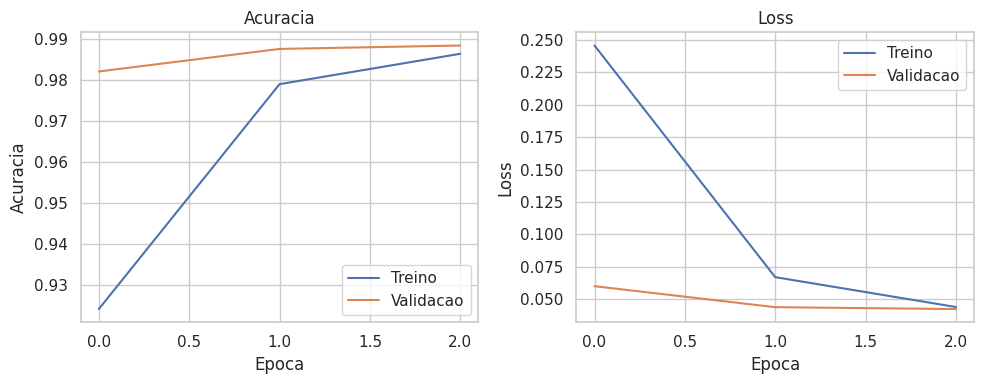

In [9]:
history_dict = history.history
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Treino')
plt.plot(history_dict['val_accuracy'], label='Validacao')
plt.title('Acuracia')
plt.xlabel('Epoca')
plt.ylabel('Acuracia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Treino')
plt.plot(history_dict['val_loss'], label='Validacao')
plt.title('Loss')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Avaliacao no teste original

A avaliacao final usa as 10000 imagens do conjunto de teste original do MNIST, preservando o split oficial da base.

In [10]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
pred_proba = model.predict(test_images, batch_size=BATCH_SIZE, verbose=0)
pred_labels = np.argmax(pred_proba, axis=1)
sklearn_accuracy = accuracy_score(test_labels, pred_labels)

print(f'Loss no teste: {test_loss:.4f}')
print(f'Acuracia no teste pelo Keras: {test_accuracy:.4f}')
print(f'Acuracia no teste pelo Scikit-Learn: {sklearn_accuracy:.4f}')

Loss no teste: 0.0342
Acuracia no teste pelo Keras: 0.9887
Acuracia no teste pelo Scikit-Learn: 0.9887


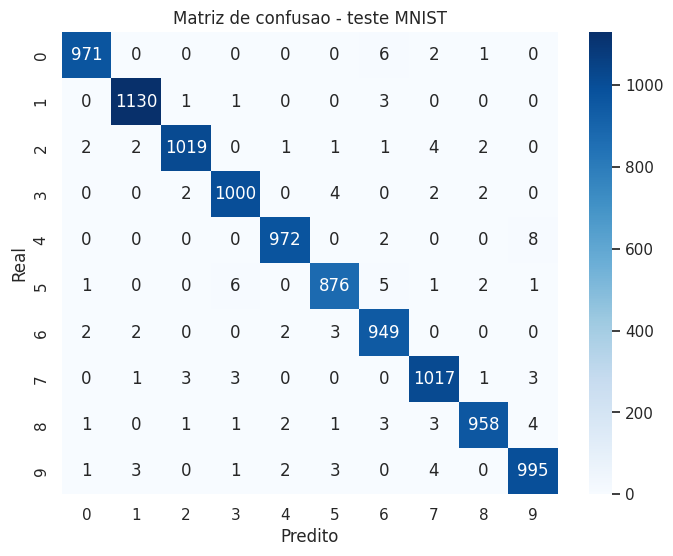

In [11]:
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusao - teste MNIST')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

## Exemplos de erros

A celula abaixo mostra ate 10 erros de classificacao. Se o modelo nao errar nenhuma imagem, ela mostra 10 predicoes corretas.

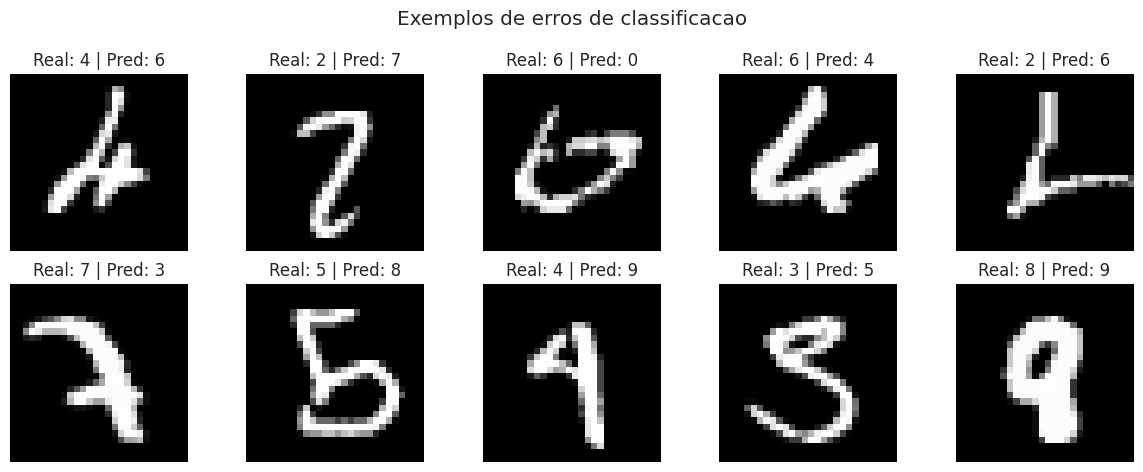

Quantidade de erros no teste: 113


In [12]:
errors = np.where(pred_labels != test_labels)[0]
if len(errors) > 0:
    selected = errors[:10]
    title = 'Exemplos de erros de classificacao'
else:
    selected = np.where(pred_labels == test_labels)[0][:10]
    title = 'Exemplos de predicoes corretas'

cols = 5
rows = int(np.ceil(len(selected) / cols))
plt.figure(figsize=(12, max(3, rows * 2.4)))
for i, idx in enumerate(selected):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(test_images_raw[idx], cmap='gray')
    plt.title(f'Real: {test_labels[idx]} | Pred: {pred_labels[idx]}')
    plt.axis('off')
plt.suptitle(title)
plt.tight_layout()
plt.show()

print('Quantidade de erros no teste:', len(errors))

## Conclusao

O notebook baixou os quatro arquivos IDX do MNIST original, fez a leitura manual do formato binario, normalizou as imagens para `[0, 1]` e ajustou o formato para `(N, 28, 28, 1)`, adequado para CNNs no Keras. A rede convolucional treinada com o conjunto completo de `60000` imagens foi avaliada no conjunto de teste original com `10000` imagens.